# TP1 - Découverte et Valeurs Manquantes Simples

**Difficulté:** Débutant  
**Dataset:** ecommerce_simple.csv  
**Description:** Introduction au nettoyage avec gestion basique des valeurs manquantes

---


## Imports des Bibliothèques


In [3]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [4]:
# Charger le dataset
df = pd.read_csv('../data/ecommerce_simple.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 500 lignes × 8 colonnes
 Taille mémoire: 0.13 MB




,order_id,customer_id,product,price,quantity,category,order_date,shipping_address
0,1,8270,Laptop,1463.85,2,Accessories,2023-01-01 00:00:00,NaN
1,2,1860,Phone,761.59,3,Electronics,2023-01-01 01:00:00,"4 Main St, City"
2,3,6390,Phone,1098.20,4,Electronics,2023-01-01 02:00:00,NaN
3,4,6191,Headphones,1240.25,4,Accessories,2023-01-01 03:00:00,NaN
4,5,6734,Laptop,1091.76,3,Electronics,2023-01-01 04:00:00,NaN




<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   product           500 non-null    str    
 3   price             455 non-null    float64
 4   quantity          500 non-null    int64  
 5   category          500 non-null    str    
 6   order_date        500 non-null    str    
 7   shipping_address  234 non-null    str    
dtypes: float64(1), int64(3), str(4)
memory usage: 31.4 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

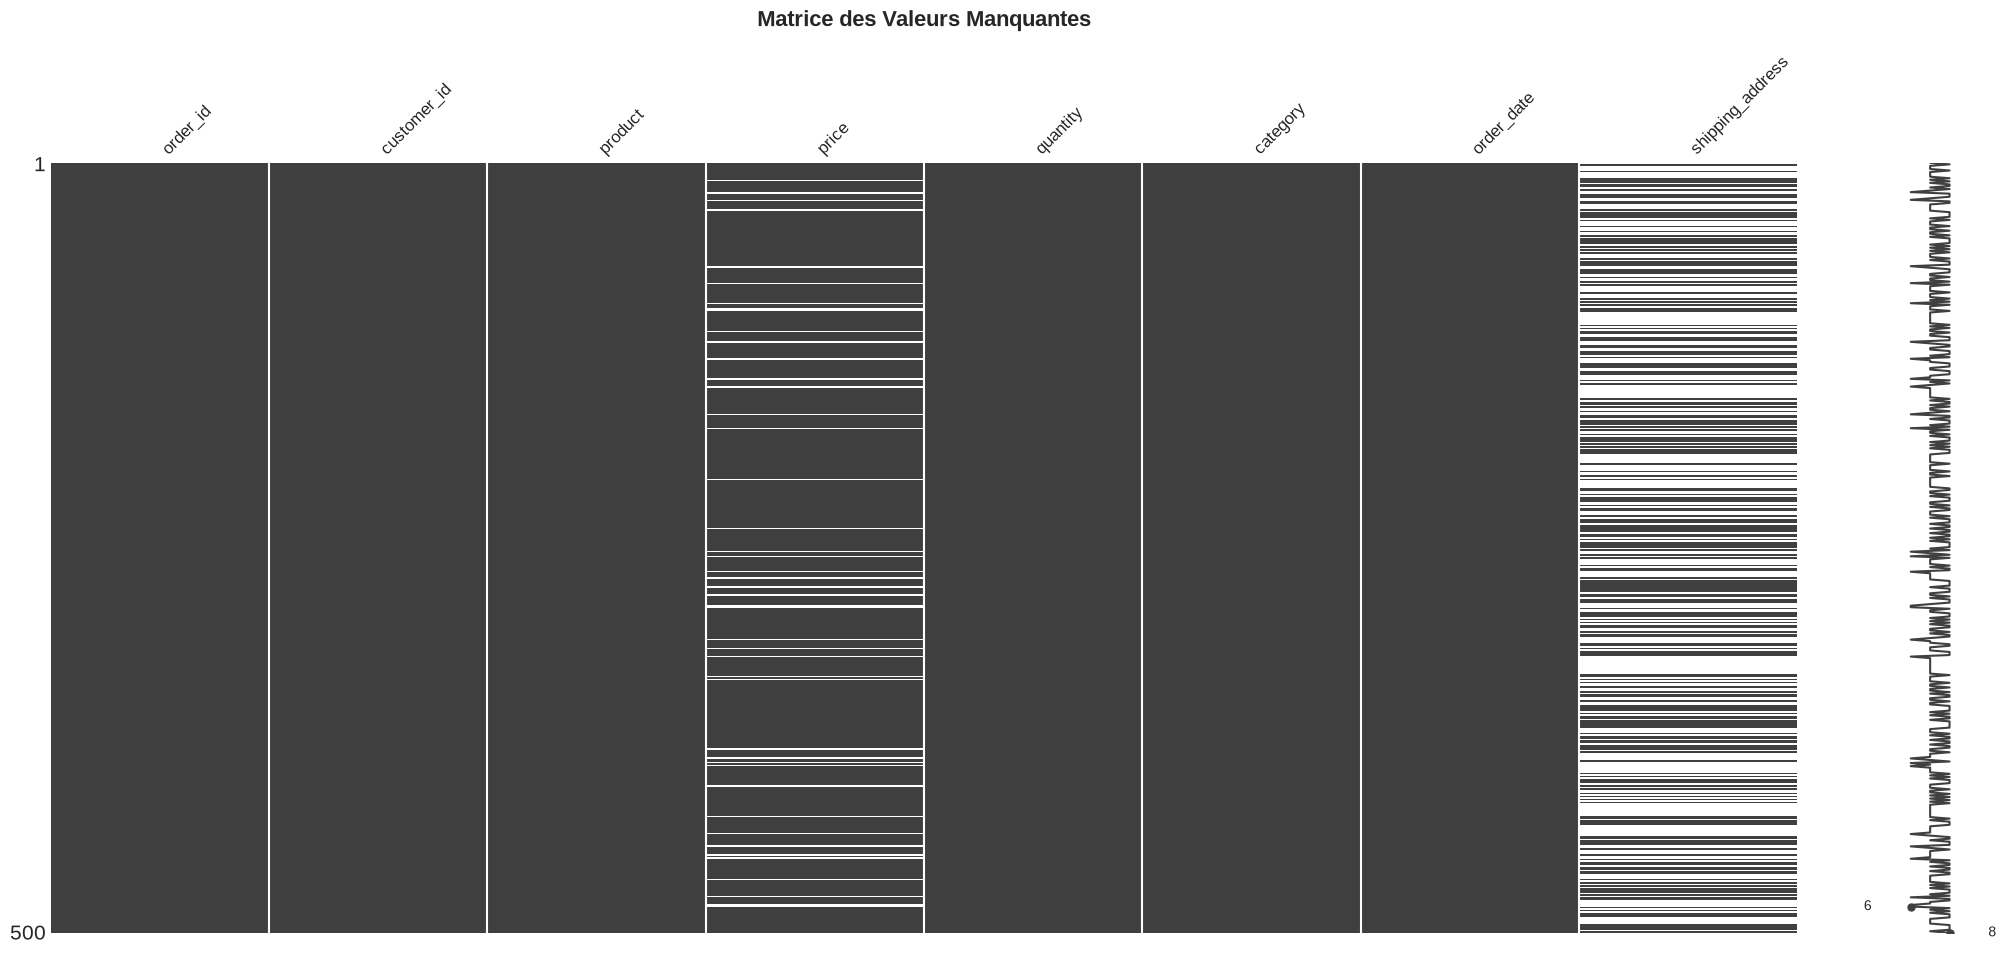


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing
shipping_address,266,53.20
price,45,9.00


In [5]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])



## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Combien de lignes et colonnes contient le dataset ?
2. Quelles colonnes contiennent des valeurs manquantes ?
3. Quel est le pourcentage de valeurs manquantes par colonne ?
4. Quelle colonne a le plus de valeurs manquantes ?
5. Y a-t-il des colonnes avec plus de 50% de valeurs manquantes ?
6. Combien de lignes sont complètes (sans aucune valeur manquante) ?
7. Quelle est la moyenne de la colonne 'price' ?
8. Combien de catégories uniques dans la colonne 'category' ?
9. Y a-t-il des valeurs négatives dans les colonnes numériques ?
10. Quelle est la date la plus ancienne dans le dataset ?


In [6]:
#1. Combien de lignes et colonnes contient le dataset ?
print(df.shape)
print("8 colonnes et 500 lignes")

(500, 8)
8 colonnes et 500 lignes


In [7]:
#2. Quelles colonnes contiennent des valeurs manquantes ?
df.isna().sum()[df.isna().sum() > 0]

price                45
shipping_address    266
dtype: int64

In [8]:
#3. Quel est le pourcentage de valeurs manquantes par colonne ?
df.isna().sum() / len(df) * 100

order_id            0.00
customer_id         0.00
product             0.00
price               9.00
quantity            0.00
category            0.00
order_date          0.00
shipping_address   53.20
dtype: float64

In [9]:
#4. Quelle colonne a le plus de valeurs manquantes ?
df.isna().sum().idxmax()

'shipping_address'

In [10]:
#5. Y a-t-il des colonnes avec plus de 50% de valeurs manquantes ?
df.isna().sum().sort_values(ascending=False) / len(df) * 100 > 50

shipping_address     True
price               False
customer_id         False
order_id            False
product             False
quantity            False
category            False
order_date          False
dtype: bool

In [11]:
#6 Combien de lignes sont complètes (sans aucune valeur manquante) ?
len(df.dropna())

216

In [12]:
#7 Quelle est la moyenne de la colonne 'price' ?
df.price.mean().round(2)

np.float64(796.07)

In [13]:
#8 Combien de catégories uniques dans la colonne 'category' ?
len(df.category.unique())

2

In [14]:
#9. Y a-t-il des valeurs négatives dans les colonnes numériques ?
(df.select_dtypes(include="number") < 0).sum()

order_id       0
customer_id    0
price          0
quantity       0
dtype: int64

In [15]:
#10. Quelle est la date la plus ancienne dans le dataset ?
pd.to_datetime(df.order_date, errors="coerce").sort_values().iloc[0]

Timestamp('2023-01-01 00:00:00')

In [16]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.


print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
print("8 colognnes et 500 lignes")
print("shipping_address et price")
print("respectivement 53.20% et 9%")
print("shipping_address avec 266")
print("oui shipping_adresse")
print("216")



Réponses aux questions:
8 colognnes et 500 lignes
shipping_address et price
respectivement 53.20% et 9%
shipping_address avec 266
oui shipping_adresse
216


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Importer et afficher les 5 premières lignes du dataset
### Étape 2: Afficher les informations générales (df.info())
### Étape 3: Calculer le pourcentage de valeurs manquantes par colonne
### Étape 4: Supprimer les colonnes avec plus de 70% de valeurs manquantes
### Étape 5: Remplir les valeurs manquantes numériques avec la médiane
### Étape 6: Remplir les valeurs manquantes catégorielles avec le mode
### Étape 7: Vérifier qu'il ne reste plus de valeurs manquantes
### Étape 8: Afficher un résumé des transformations effectuées


In [17]:
# ========================================
# Étape 1: Importer et afficher les 5 premières lignes du dataset
# ========================================

# TODO: Écrivez votre code ici
ecommerce_simple = pd.read_csv("../data/ecommerce_simple.csv")
display(ecommerce_simple.head(5))


# Vérification
print(f"Étape 1 complétée")

,order_id,customer_id,product,price,quantity,category,order_date,shipping_address
0,1,8270,Laptop,1463.85,2,Accessories,2023-01-01 00:00:00,NaN
1,2,1860,Phone,761.59,3,Electronics,2023-01-01 01:00:00,"4 Main St, City"
2,3,6390,Phone,1098.20,4,Electronics,2023-01-01 02:00:00,NaN
3,4,6191,Headphones,1240.25,4,Accessories,2023-01-01 03:00:00,NaN
4,5,6734,Laptop,1091.76,3,Electronics,2023-01-01 04:00:00,NaN


Étape 1 complétée


In [18]:
# ========================================
# Étape 2: Afficher les informations générales (df.info())
# ========================================

# TODO: Écrivez votre code ici
ecommerce_simple.info()

# Vérification
print(f"Étape 2 complétée")

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   product           500 non-null    str    
 3   price             455 non-null    float64
 4   quantity          500 non-null    int64  
 5   category          500 non-null    str    
 6   order_date        500 non-null    str    
 7   shipping_address  234 non-null    str    
dtypes: float64(1), int64(3), str(4)
memory usage: 31.4 KB
Étape 2 complétée


In [19]:
# ========================================
# Étape 3: Calculer le pourcentage de valeurs manquantes par colonne
# ========================================

# TODO: Écrivez votre code ici
print(ecommerce_simple.isna().sum() / len(ecommerce_simple) * 100)

# Vérification
print(f"Étape 3 complétée")

order_id            0.00
customer_id         0.00
product             0.00
price               9.00
quantity            0.00
category            0.00
order_date          0.00
shipping_address   53.20
dtype: float64
Étape 3 complétée


In [20]:
# ========================================
# Étape 4: Supprimer les colonnes avec plus de 70% de valeurs manquantes
# ========================================

# TODO: Écrivez votre code ici
ecommerce_simple_clean = ecommerce_simple.dropna(axis=1, thresh=int(len(ecommerce_simple) * 0.3))

# Vérification
print(f"Étape 4 complétée")

Étape 4 complétée


In [21]:
# ========================================
# Étape 5: Remplir les valeurs manquantes numériques avec la médiane
# ========================================

# TODO: Écrivez votre code ici
ecommerce_simple_clean = ecommerce_simple.fillna(ecommerce_simple.median(numeric_only=True))

# Vérification
print(f"Étape 5 complétée")

Étape 5 complétée


In [22]:
# ========================================
# Étape 6: Remplir les valeurs manquantes catégorielles avec le mode
# ========================================

# TODO: Écrivez votre code ici
ecommerce_simple_clean.shipping_address = ecommerce_simple.shipping_address.fillna(ecommerce_simple.shipping_address.mode()[0])

# Vérification
print(f"Étape 6 complétée")

Étape 6 complétée


In [23]:
# ========================================
# Étape 7: Vérifier qu'il ne reste plus de valeurs manquantes
# ========================================

# TODO: Écrivez votre code ici
ecommerce_simple_clean.isna().sum().sum()

# Vérification
print(f"Étape 7 complétée")

Étape 7 complétée


In [24]:
# ========================================
# Étape 8: Afficher un résumé des transformations effectuées
# ========================================

# TODO: Écrivez votre code ici
# Supprimer les colonnes avec plus de 70% de valeurs manquantes
# Remplir les valeurs manquantes numériques avec la médiane
# Remplir les valeurs manquantes catégorielles avec le mode

# Vérification
print(f"Étape 8 complétée")

Étape 8 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [ ]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': ecommerce_simple.shape,
    'Dimensions_finales': ecommerce_simple_clean.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': ecommerce_simple.shape[0] - ecommerce_simple_clean.shape[0],
    'Colonnes_supprimées': ecommerce_simple.shape[1] - ecommerce_simple_clean.shape[1],
    'Valeurs_manquantes_traitées': ecommerce_simple.isna().sum().sum() - ecommerce_simple_clean.isna().sum().sum(),
    'Doublons_supprimés': ecommerce_simple.duplicated().sum() - ecommerce_simple_clean.duplicated().sum(),
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (500, 8)
Dimensions_finales...................... (500, 8)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 311
Doublons_supprimés...................... 0
Outliers_traités........................ 0
Transformations_appliquées.............. []

 TP terminé avec succès!
